importing google finance dataset and some libraries 

In [36]:
import numpy as np
import pandas
import seaborn as sns
import pandas as pd
import yfinance as yf
from datetime import datetime as dt
import matplotlib.pyplot as plt
import cufflinks as cf
import plotly.express as px

cf.go_offline()
cf.set_config_file(offline=True)
%matplotlib inline


In [2]:
start = dt(2010, 1, 1)
end = dt(2020, 1, 1)

In [3]:
# get the stock quote for Apple, Google and Microsoft

AAPL = yf.download('AAPL', start=start, end=end)

GOOG = yf.download('GOOG', start=start, end=end)

MSFT = yf.download('MSFT', start=start, end=end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
ticks = ['AAPL', 'GOOG', 'MSFT']
data = yf.download(ticks, start=start, end=end)

[*********************100%***********************]  3 of 3 completed


In [5]:
data_tech = pd.concat([AAPL , GOOG , MSFT], axis=1 , keys= ticks)

In [6]:
data_tech

AAPL                                                   GOOG  \
Price           Close       High        Low       Open     Volume      Close   
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL       GOOG   
Date                                                                           
2010-01-04   6.412383   6.427064   6.363543   6.395004  493729600  15.483123   
2010-01-05   6.423469   6.459724   6.389610   6.430061  601904800  15.414941   
2010-01-06   6.321297   6.448940   6.314705   6.423471  552160000  15.026350   
2010-01-07   6.309611   6.352159   6.263768   6.344668  477131200  14.676543   
2010-01-08   6.351559   6.352158   6.264067   6.301221  447610800  14.872199   
...               ...        ...        ...        ...        ...        ...   
2019-12-24  68.524376  68.673835  68.198959  68.625622   48478800  66.630959   
2019-12-26  69.883926  69.900802  68.628038  68.656963   93121200  67.466103   
2019-12-27  69.857384  70.862581  69.452415  70.175576  146266000  67.044067   
2019-12-30  70.271996  70.554032  68.753360  69.775425  144114400  66.262985   
2019-12-31  70.785454  70.792685  69.789900  69.888733  100805600  66.306618   

                                                              MSFT  \
Price            High        Low       Open     Volume       Close   
Ticker           GOOG       GOOG       GOOG       GOOG        MSFT   
Date                                                                 
2010-01-04  15.551305  15.421116  15.488063   78541293   23.077383   
2010-01-05  15.510050  15.354416  15.493745  120638494   23.084835   
2010-01-06  15.461137  14.979413  15.461137  159744526   22.943171   
2010-01-07  15.069335  14.640723  15.054512  257533695   22.704567   
2010-01-08  14.902584  14.553273  14.624666  189680313   22.861141   
...               ...        ...        ...        ...         ...   
2019-12-24  66.963230  66.592275  66.875949    6950000  149.089050   
2019-12-26  67.512081  66.676095  66.760402   13350000  150.311142   
2019-12-27  67.670925  66.916120  67.594548   20768000  150.585831   
2019-12-30  67.099123  66.157846  66.950343   21018000  149.288055   
2019-12-31  66.355222  65.913097  65.963934   19236000  149.392181   

                                                          
Price             High         Low        Open    Volume  
Ticker            MSFT        MSFT        MSFT      MSFT  
Date                                                      
2010-01-04   23.189228   22.808954   22.831324  38409100  
2010-01-05   23.189225   22.846232   23.002816  49749600  
2010-01-06   23.174317   22.756762   23.025189  58182400  
2010-01-07   22.890976   22.510702   22.838780  50559700  
2010-01-08   23.025180   22.547975   22.577801  51197400  
...                ...         ...         ...       ...  
2019-12-24  149.401667  148.842738  149.183774   8989200  
2019-12-26  150.367979  149.108042  149.259617  14520600  
2019-12-27  151.144745  149.884809  151.050008  18412800  
2019-12-30  150.642730  148.473360  150.614311  16348400  
2019-12-31  149.458501  148.208033  148.511182  18369400  

[2516 rows x 15 columns]

In [7]:
returns = pd.DataFrame()
for tick in ticks:
    returns[tick + 'Returns'] = data_tech[tick]['Close'].pct_change()

In [8]:
returns 

,AAPLReturns,GOOGReturns,MSFTReturns
Date,,,
2010-01-04,NaN,NaN,NaN
2010-01-05,0.001729,-0.004404,0.000323
2010-01-06,-0.015906,-0.025209,-0.006137
2010-01-07,-0.001849,-0.023280,-0.010400
2010-01-08,0.006648,0.013331,0.006896
...,...,...,...
2019-12-24,0.000951,-0.003915,-0.000191
2019-12-26,0.019840,0.012534,0.008197
2019-12-27,-0.000380,-0.006256,0.001827


In [9]:
returns = returns.dropna()

In [10]:
returns

,AAPLReturns,GOOGReturns,MSFTReturns
Date,,,
2010-01-05,0.001729,-0.004404,0.000323
2010-01-06,-0.015906,-0.025209,-0.006137
2010-01-07,-0.001849,-0.023280,-0.010400
2010-01-08,0.006648,0.013331,0.006896
2010-01-11,-0.008822,-0.001512,-0.012720
...,...,...,...
2019-12-24,0.000951,-0.003915,-0.000191
2019-12-26,0.019840,0.012534,0.008197
2019-12-27,-0.000380,-0.006256,0.001827


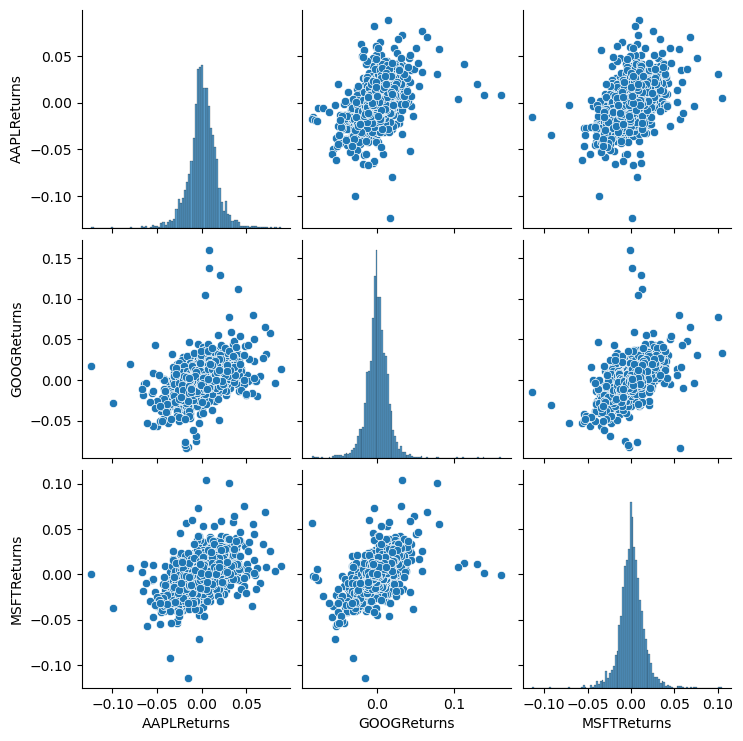

In [47]:
sns.pairplot(returns , kind='scatter')

In [17]:
for i in returns.columns:
    print(' for ' + i + ': maxi day is ' + str(returns[i].idxmax()) + ' and mini day is ' + str(returns[i].idxmin()) )

 for AAPLReturns: maxi day is 2012-04-25 00:00:00 and mini day is 2013-01-24 00:00:00
 for GOOGReturns: maxi day is 2015-07-17 00:00:00 and mini day is 2012-01-20 00:00:00
 for MSFTReturns: maxi day is 2015-04-24 00:00:00 and mini day is 2013-07-19 00:00:00


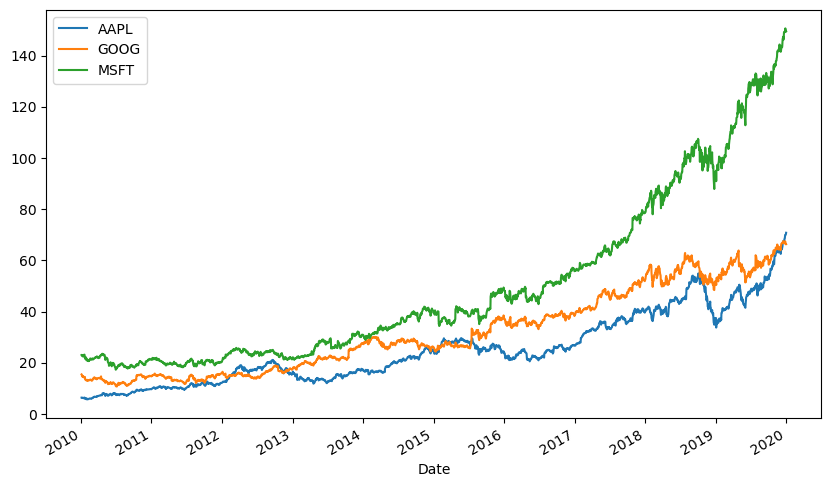

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))

for tick in ticks:
    data_tech[tick]['Close'].plot(ax=ax, label=tick)

ax.legend()


# or 
# data.xs('Close', axis=1).plot()

In [40]:
df = data.xs('Close', axis=1)
df.index = df.index.astype(str)

fig = px.line(df, title="Tech Close Prices")
fig.show()

# Analysis Summary and Insights
## Insights Extracted

### Stock Price Trends (2010-2020)
- All three tech giants showed significant growth over the decade.
- Apple (AAPL) experienced the most volatile price movements, with closing prices ranging from around $25 to over $300.
- Google (GOOG) and Microsoft (MSFT) showed more steady upward trends, with GOOG reaching around $1,500 and MSFT around $220 by 2020.

### Returns Analysis
- Daily returns were calculated as percentage changes in closing prices.
- The pairplot revealed moderate positive correlations between the returns of these tech stocks, indicating they often move in similar directions due to market influences.

### Extreme Return Days
- **Apple (AAPL)**: Maximum return day was [2012-04-25], minimum was [2013-01-24]
- **Google (GOOG)**: Maximum return day was [2015-07-17], minimum was [2012-01-20]  
- **Microsoft (MSFT)**: Maximum return day was [2015-04-24], minimum was [2013-07-19]


### Visualization Insights
- The Matplotlib plot provides a clear, static view of price trends.
- The Plotly interactive plot allows for zooming and hovering to examine specific time periods in detail.

This analysis provides a foundation for understanding the historical performance and relationships between these major tech stocks. Further analysis could include risk metrics, portfolio optimization, or predictive modeling.